<a href="https://colab.research.google.com/github/amodita-a/sea-ad-microglia-analysis/blob/main/notebooks/01_sea_ad_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SEA-AD Dataset Exploration

This notebook documents the initial exploration of publicly available data from the Seattle Alzheimer's Disease Brain Cell Atlas (SEA-AD).

The goal is to identify the relevant middle temporal gyrus dataset, inspect available donor and cell metadata, isolate microglial nuclei, and prepare the data for a donor-level analysis of immune-related gene programs.

This is an independent educational reanalysis of publicly available research data.

In [ ]:
!pip install -q cellxgene-census scanpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 78.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.6/206.6 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc
import cellxgene_census

!pip install --upgrade numpy scipy scanpy cellxgene-census

print("pandas:", pd.__version__)
print("scanpy:", sc.__version__)
print("cellxgene_census imported successfully")

AttributeError: module 'numpy._core._multiarray_umath' has no attribute '_blas_supports_fpe'

In [ ]:
!pip install --upgrade numpy scipy scanpy cellxgene-census

import numpy as np
import scipy
import pandas as pd
import scanpy as sc
import cellxgene_census

print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("pandas:", pd.__version__)
print("Scanpy:", sc.__version__)
print("CELLxGENE Census imported successfully")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 23.3 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.3 requires numba<=0.65.1,>=0.58, but you have numba 0.67.0 which is incompatible.
NumPy: 2.5.2
SciPy: 1.18.0
pandas: 2.3.3
Scanpy: 1.12.3
CELLxGENE Census imported successfully


/tmp/ipykernel_3823/416554974.py:12: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("Scanpy:", sc.__version__)


In [ ]:
# Open the CELLxGENE Census
census = cellxgene_census.open_soma()

# Load the dataset metadata table
datasets = (
    census["census_info"]["datasets"]
    .read()
    .concat()
    .to_pandas()
)

print("Number of datasets in Census:", len(datasets))
print(datasets.columns.tolist())

The "stable" release is currently 2025-11-08. Specify 'census_version="2025-11-08"' in future calls to open_soma() to ensure data consistency.
INFO:cellxgene_census:The "stable" release is currently 2025-11-08. Specify 'census_version="2025-11-08"' in future calls to open_soma() to ensure data consistency.


Number of datasets in Census: 1845
['soma_joinid', 'citation', 'collection_id', 'collection_name', 'collection_doi', 'collection_doi_label', 'dataset_id', 'dataset_version_id', 'dataset_title', 'dataset_h5ad_path', 'dataset_total_cell_count']


In [ ]:
# Search the dataset table for SEA-AD
sea_ad = datasets[
    datasets["collection_name"]
    .str.contains("SEA-AD", case=False, na=False)
]

print("SEA-AD datasets found:", len(sea_ad))

sea_ad[
    [
        "collection_name",
        "dataset_title",
        "dataset_id",
        "dataset_total_cell_count"
    ]
]

SEA-AD datasets found: 50


,collection_name,dataset_title,dataset_id,dataset_total_cell_count
298,SEA-AD: Seattle Alzheimer’s Disease Brain Cell...,Endothelial - MTG: Seattle Alzheimer's Disease...,3e87b1fa-472a-401c-8fa8-f31c10437d5f,2069
363,SEA-AD: Seattle Alzheimer’s Disease Brain Cell...,Sst Chodl - MTG: Seattle Alzheimer's Disease A...,81e91ff8-f619-4ad1-a0c3-b45e1dc63f68,1496
410,SEA-AD: Seattle Alzheimer’s Disease Brain Cell...,Endothelial - DLPFC: Seattle Alzheimer's Disea...,2ecc72f8-085f-4e86-8692-771f316c54f6,2575
453,SEA-AD: Seattle Alzheimer’s Disease Brain Cell...,VLMC - MTG: Seattle Alzheimer's Disease Atlas ...,236baeda-5fdd-41bf-8e32-bae21ac7d435,4328
518,SEA-AD: Seattle Alzheimer’s Disease Brain Cell...,Sst Chodl - DLPFC: Seattle Alzheimer's Disease...,fc0ceb80-d2d9-47c1-9d78-b0e45c64c500,1877
560,SEA-AD: Seattle Alzheimer’s Disease Brain Cell...,VLMC - DLPFC: Seattle Alzheimer's Disease Atla...,2e5a9b5d-d31b-4e9f-a179-d5d70ba459fb,4860
617,SEA-AD: Seattle Alzheimer’s Disease Brain Cell...,L5 ET - MTG: Seattle Alzheimer's Disease Atlas...,07428d73-fdea-4bd4-a801-94b00c4d961c,2590
908,SEA-AD: Seattle Alzheimer’s Disease Brain Cell...,Chandelier - MTG: Seattle Alzheimer's Disease ...,8c6ed88f-11bf-4159-bad7-ff41fb1e1eca,10928
910,SEA-AD: Seattle Alzheimer’s Disease Brain Cell...,Pax6 - MTG: Seattle Alzheimer's Disease Atlas ...,f67f2cfa-ba45-4f77-8e26-64a15f666043,9203
943,SEA-AD: Seattle Alzheimer’s Disease Brain Cell...,L5 ET - DLPFC: Seattle Alzheimer's Disease Atl...,6cda07c7-5d7a-41ba-9799-5bb73da25a60,4097


In [ ]:
datasets["collection_name"].str.contains("SEA-AD")

,collection_name
0,False
1,False
2,False
3,False
4,False
...,...
1840,False
1841,False
1842,False
1843,True


In [ ]:
# Dataset ID for SEA-AD Microglia-PVM, middle temporal gyrus
microglia_mtg_id = "c76098ba-eed3-45b1-98f2-96fcac55ed18"

# Fetch CELL METADATA ONLY — not the gene-expression matrix
microglia_meta = cellxgene_census.get_obs(
    census,
    "homo_sapiens",
    value_filter=f"dataset_id == '{microglia_mtg_id}'"
)

print("Metadata rows:", len(microglia_meta))
print("Metadata columns:")
print(microglia_meta.columns.tolist())

# Preview the metadata
microglia_meta.head()

print("Unique donors:", microglia_meta["donor_id"].nunique())

print("\nCell types:")
print(microglia_meta["cell_type"].value_counts())

print("\nDisease labels:")
print(microglia_meta["disease"].value_counts())

print("\nSex:")
print(microglia_meta["sex"].value_counts())

print("\nAssay:")
print(microglia_meta["assay"].value_counts())

print("\nTissue:")
print(microglia_meta["tissue"].value_counts())

# Number of nuclei contributed by each donor
donor_counts = (
    microglia_meta
    .groupby("donor_id")
    .size()
    .sort_values(ascending=False)
)

print(donor_counts)

Metadata rows: 40000
Metadata columns:
['soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars']
Unique donors: 89

Cell types:
cell_type
microglial cell                                    40000
microcirculation associated smooth muscle cell         0
microfold cell of epithelium of small intestine        0
midbrain dopaminergic neuron                           0
midget ganglion cell of retina                         0
                                                   ...  
endothelial cell of 

/tmp/ipykernel_3823/3302101181.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("donor_id")


In [ ]:
# Show only categories that are actually present

print("Cell types:")
print(
    microglia_meta["cell_type"]
    .value_counts()
    .loc[lambda x: x > 0]
)

print("\nDisease labels:")
print(
    microglia_meta["disease"]
    .value_counts()
    .loc[lambda x: x > 0]
)

print("\nSex:")
print(
    microglia_meta["sex"]
    .value_counts()
    .loc[lambda x: x > 0]
)

print("\nAssay:")
print(
    microglia_meta["assay"]
    .value_counts()
    .loc[lambda x: x > 0]
)

print("\nTissue:")
print(
    microglia_meta["tissue"]
    .value_counts()
    .loc[lambda x: x > 0]
)

Cell types:
cell_type
microglial cell    40000
Name: count, dtype: int64

Disease labels:
disease
normal      20124
dementia    19876
Name: count, dtype: int64

Sex:
sex
female    23249
male      16751
Name: count, dtype: int64

Assay:
assay
10x 3' v3       35889
10x multiome     4111
Name: count, dtype: int64

Tissue:
tissue
middle temporal gyrus    40000
Name: count, dtype: int64


In [ ]:
# Number of microglial nuclei contributed by each actual donor
donor_counts = (
    microglia_meta
    .groupby("donor_id", observed=True)
    .size()
    .sort_values(ascending=False)
)

print("Number of actual donors:", len(donor_counts))
print("\nNuclei per donor:")
print(donor_counts)

print("\nSummary:")
print(donor_counts.describe())

Number of actual donors: 89

Nuclei per donor:
donor_id
H20.33.028    1077
H21.33.027    1068
H21.33.043     972
H21.33.010     964
H21.33.022     929
              ... 
H20.33.024     127
H21.33.020     118
H20.33.037      79
H18.30.001       1
H200.1023        1
Length: 89, dtype: int64

Summary:
count      89.000000
mean      449.438202
std       253.971722
min         1.000000
25%       265.000000
50%       391.000000
75%       594.000000
max      1077.000000
dtype: float64


In [ ]:
# Check whether each donor has exactly one disease label
disease_per_donor = (
    microglia_meta
    .groupby("donor_id", observed=True)["disease"]
    .nunique()
)

print("Disease labels per donor:")
print(disease_per_donor.value_counts())

print("\nDonors with more than one disease label:")
print(disease_per_donor[disease_per_donor > 1])

Disease labels per donor:
disease
1    89
Name: count, dtype: int64

Donors with more than one disease label:
Series([], Name: disease, dtype: int64)


In [ ]:
# Create a donor-level metadata table
donor_meta = (
    microglia_meta[
        ["donor_id", "disease", "sex", "assay"]
    ]
    .drop_duplicates()
)

print("Rows in donor metadata table:", len(donor_meta))
donor_meta.head(10)

Rows in donor metadata table: 116


,donor_id,disease,sex,assay
0,H21.33.008,dementia,female,10x 3' v3
1,H21.33.014,normal,male,10x 3' v3
2,H20.33.015,dementia,male,10x 3' v3
3,H21.33.011,normal,female,10x 3' v3
4,H21.33.040,normal,male,10x 3' v3
5,H20.33.040,dementia,male,10x 3' v3
6,H20.33.025,normal,male,10x 3' v3
7,H21.33.022,normal,female,10x 3' v3
9,H21.33.029,dementia,male,10x 3' v3
10,H20.33.033,dementia,male,10x 3' v3


In [ ]:
# Build a clean one-row-per-donor metadata table

donor_meta_clean = (
    microglia_meta[
        ["donor_id", "disease", "sex"]
    ]
    .drop_duplicates()
    .sort_values("donor_id")
    .reset_index(drop=True)
)

print("Rows:", len(donor_meta_clean))
print("Unique donors:", donor_meta_clean["donor_id"].nunique())

donor_meta_clean.head(10)

Rows: 89
Unique donors: 89


,donor_id,disease,sex
0,H18.30.001,normal,female
1,H18.30.002,normal,male
2,H19.30.001,normal,male
3,H19.30.002,normal,male
4,H19.33.004,normal,female
5,H20.33.001,normal,male
6,H20.33.002,normal,female
7,H20.33.004,dementia,male
8,H20.33.005,normal,female
9,H20.33.008,normal,female


In [ ]:
print("Donor-level disease counts:")
print(donor_meta_clean["disease"].value_counts())

Donor-level disease counts:
disease
normal                                                       47
dementia                                                     42
kidney benign neoplasm                                        0
kidney oncocytoma                                             0
leukoencephalopathy, diffuse hereditary, with spheroids 1     0
                                                             ..
dementia || Alzheimer disease || Lewy body dementia           0
dementia || Alzheimer disease                                 0
cytomegalovirus infection                                     0
cystic fibrosis                                               0
dementia || Alzheimer disease || diabetes mellitus            0
Name: count, Length: 259, dtype: int64


In [ ]:
print("Donor-level sex counts:")
print(donor_meta_clean["sex"].value_counts())

Donor-level sex counts:
sex
female     53
male       36
unknown     0
Name: count, dtype: int64


In [ ]:
import pandas as pd

# Official SEA-AD donor metadata
donor_metadata_url = (
    "https://brainmapportal-live-4cc80a57cd6e400d854-f7fdcae.divio-media.net/"
    "filer_public/b4/c7/b4c727e1-ede1-4c61-b2ee-bf1ae4a3ef68/"
    "sea-ad_cohort_donor_metadata_072524.xlsx"
)

seaad_donors = pd.read_excel(donor_metadata_url)

print("Rows:", len(seaad_donors))
print("Columns:")
print(seaad_donors.columns.tolist())

seaad_donors.head()

URLError: <urlopen error [Errno -2] Name or service not known>

In [ ]:
import pandas as pd
import os

print(os.listdir("/content"))

['.config', '68debdfdd1b8e9f8fd64dab0_sea-ad_cohort_donor_metadata_072524.xlsx', 'sample_data']


In [ ]:
seaad_donors = pd.read_excel("/content/YOUR_FILENAME.xlsx")

print("Rows:", len(seaad_donors))
print("Columns:")
print(seaad_donors.columns.tolist())

seaad_donors.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/YOUR_FILENAME.xlsx'

In [ ]:
seaad_donors = pd.read_excel(
    "/content/68debdfdd1b8e9f8fd64dab0_sea-ad_cohort_donor_metadata_072524.xlsx"
)

print("Rows:", len(seaad_donors))
print("Columns:")
print(seaad_donors.columns.tolist())

seaad_donors.head()

Rows: 84
Columns:
['Donor ID', 'Primary Study Name', 'Secondary Study Name', 'Age at Death', 'Sex', 'Race (choice=White)', 'Race (choice=Black/ African American)', 'Race (choice=Asian)', 'Race (choice=American Indian/ Alaska Native)', 'Race (choice=Native Hawaiian or Pacific Islander)', 'Race (choice=Unknown or unreported)', 'Race (choice=Other)', 'specify other race', 'Hispanic/Latino', 'Highest level of education', 'Years of education', 'APOE Genotype', 'Cognitive Status', 'Age of onset cognitive symptoms', 'Age of Dementia diagnosis', 'Known head injury', 'Have they had neuroimaging', 'Consensus Clinical Dx (choice=Alzheimers disease)', 'Consensus Clinical Dx (choice=Alzheimers Possible/ Probable)', 'Consensus Clinical Dx (choice=Ataxia)', 'Consensus Clinical Dx (choice=Corticobasal Degeneration)', 'Consensus Clinical Dx (choice=Control)', 'Consensus Clinical Dx (choice=Dementia with Lewy Bodies/ Lewy Body Disease)', 'Consensus Clinical Dx (choice=Frontotemporal lobar degeneration)'

,Donor ID,Primary Study Name,Secondary Study Name,Age at Death,Sex,Race (choice=White),Race (choice=Black/ African American),Race (choice=Asian),Race (choice=American Indian/ Alaska Native),Race (choice=Native Hawaiian or Pacific Islander),...,CERAD score,Overall CAA Score,Highest Lewy Body Disease,Total Microinfarcts (not observed grossly),Total microinfarcts in screening sections,Atherosclerosis,Arteriolosclerosis,LATE,RIN,Severely Affected Donor
0,H19.33.004,ACT,NaN,80,Female,Checked,Unchecked,Unchecked,Unchecked,Unchecked,...,Absent,Not identified,Not Identified (olfactory bulb not assessed),1,1,Mild,Moderate,Not Identified,8.33,NaN
1,H20.33.001,ACT,NaN,82,Male,Checked,Unchecked,Unchecked,Unchecked,Unchecked,...,Sparse,Not identified,Not Identified (olfactory bulb not assessed),0,0,Mild,Mild,LATE Stage 2,8.60,NaN
2,H20.33.002,ACT,NaN,97,Female,Checked,Unchecked,Unchecked,Unchecked,Unchecked,...,Absent,Not identified,Limbic (Transitional),0,0,Moderate,Moderate,LATE Stage 2,7.87,NaN
3,H20.33.004,ACT,NaN,86,Male,Checked,Unchecked,Unchecked,Unchecked,Unchecked,...,Frequent,Moderate,Neocortical (Diffuse),0,0,Mild,Severe,LATE Stage 1,7.83,NaN
4,H20.33.005,ACT,NaN,99,Female,Checked,Unchecked,Unchecked,Unchecked,Unchecked,...,Moderate,Moderate,Not Identified (olfactory bulb not assessed),2,2,Mild,Moderate,LATE Stage 1,8.40,NaN


In [ ]:
# Compare donor IDs between CELLxGENE and the official SEA-AD metadata

cellxgene_ids = set(donor_meta_clean["donor_id"].astype(str))
seaad_ids = set(seaad_donors["Donor ID"].astype(str))

matched_ids = cellxgene_ids & seaad_ids
missing_from_metadata = cellxgene_ids - seaad_ids
metadata_not_in_cellxgene = seaad_ids - cellxgene_ids

print("CELLxGENE donors:", len(cellxgene_ids))
print("SEA-AD metadata donors:", len(seaad_ids))
print("Matched donors:", len(matched_ids))

print("\nCELLxGENE donors missing from donor metadata:")
print(sorted(missing_from_metadata))

print("\nMetadata donors not present in our CELLxGENE subset:")
print(sorted(metadata_not_in_cellxgene))

CELLxGENE donors: 89
SEA-AD metadata donors: 84
Matched donors: 84

CELLxGENE donors missing from donor metadata:
['H18.30.001', 'H18.30.002', 'H19.30.001', 'H19.30.002', 'H200.1023']

Metadata donors not present in our CELLxGENE subset:
[]


In [ ]:
# Merge our CELLxGENE donor table with official SEA-AD pathology metadata

analysis_meta = donor_meta_clean.merge(
    seaad_donors,
    left_on="donor_id",
    right_on="Donor ID",
    how="left"
)

print("Rows after merge:", len(analysis_meta))
print("Matched pathology records:", analysis_meta["Donor ID"].notna().sum())
print("Missing pathology records:", analysis_meta["Donor ID"].isna().sum())

Rows after merge: 89
Matched pathology records: 84
Missing pathology records: 5


In [ ]:
pathology_cols = [
    "donor_id",
    "disease",
    "sex",
    "Age at Death",
    "Cognitive Status",
    "Overall AD neuropathological Change",
    "Thal",
    "Braak",
    "CERAD score"
]

analysis_meta[pathology_cols].head(15)

,donor_id,disease,sex,Age at Death,Cognitive Status,Overall AD neuropathological Change,Thal,Braak,CERAD score
0,H18.30.001,normal,female,NaN,NaN,NaN,NaN,NaN,NaN
1,H18.30.002,normal,male,NaN,NaN,NaN,NaN,NaN,NaN
2,H19.30.001,normal,male,NaN,NaN,NaN,NaN,NaN,NaN
3,H19.30.002,normal,male,NaN,NaN,NaN,NaN,NaN,NaN
4,H19.33.004,normal,female,80.0,No dementia,Not AD,Thal 0,Braak IV,Absent
5,H20.33.001,normal,male,82.0,No dementia,Low,Thal 2,Braak IV,Sparse
6,H20.33.002,normal,female,97.0,No dementia,Not AD,Thal 0,Braak IV,Absent
7,H20.33.004,dementia,male,86.0,Dementia,High,Thal 5,Braak V,Frequent
8,H20.33.005,normal,female,99.0,No dementia,Intermediate,Thal 3,Braak IV,Moderate
9,H20.33.008,normal,female,92.0,No dementia,High,Thal 4,Braak V,Moderate


In [ ]:
for col in [
    "Overall AD neuropathological Change",
    "Thal",
    "Braak",
    "CERAD score"
]:
    print(f"\n{col}:")
    print(analysis_meta[col].value_counts(dropna=False))


Overall AD neuropathological Change:
Overall AD neuropathological Change
High            42
Intermediate    21
Low             12
Not AD           9
NaN              5
Name: count, dtype: int64

Thal:
Thal
Thal 4    30
Thal 5    21
Thal 3    12
Thal 0     9
Thal 2     7
NaN        5
Thal 1     5
Name: count, dtype: int64

Braak:
Braak
Braak V      34
Braak IV     23
Braak VI     15
Braak III     6
NaN           5
Braak II      4
Braak 0       2
Name: count, dtype: int64

CERAD score:
CERAD score
Frequent    30
Moderate    26
Absent      16
Sparse      12
NaN          5
Name: count, dtype: int64


In [ ]:
# Keep only donors with available AD neuropathology data
analysis_meta_complete = analysis_meta[
    analysis_meta["Overall AD neuropathological Change"].notna()
].copy()

# Create a simple two-group pathology variable
pathology_map = {
    "Not AD": "Lower pathology",
    "Low": "Lower pathology",
    "Intermediate": "Higher pathology",
    "High": "Higher pathology"
}

analysis_meta_complete["pathology_group"] = (
    analysis_meta_complete["Overall AD neuropathological Change"]
    .map(pathology_map)
)

print("Donors included:", len(analysis_meta_complete))

print("\nPathology groups:")
print(analysis_meta_complete["pathology_group"].value_counts())

Donors included: 84

Pathology groups:
pathology_group
Higher pathology    63
Lower pathology     21
Name: count, dtype: int64


In [ ]:
pd.crosstab(
    analysis_meta_complete["pathology_group"],
    analysis_meta_complete["Overall AD neuropathological Change"]
)

Overall AD neuropathological Change,High,Intermediate,Low,Not AD
pathology_group,,,,
Higher pathology,42,21,0,0
Lower pathology,0,0,12,9


In [ ]:
interferon_genes = [
    "IFI6",
    "IFI27",
    "IFI44",
    "IFI44L",
    "IFIT1",
    "IFIT2",
    "IFIT3",
    "ISG15",
    "MX1",
    "OAS1",
    "OAS2",
    "STAT1"
]

antigen_presentation_genes = [
    "HLA-DRA",
    "HLA-DRB1",
    "HLA-DPA1",
    "HLA-DPB1",
    "HLA-DQA1",
    "HLA-DQB1",
    "CD74",
    "CIITA"
]

In [ ]:
# Get the human gene/feature metadata from Census
var = (
    census["census_data"]["homo_sapiens"].ms["RNA"].var
    .read()
    .concat()
    .to_pandas()
)

print(var.columns.tolist())
print("Number of genes/features:", len(var))

['soma_joinid', 'feature_id', 'feature_name', 'feature_type', 'feature_length', 'nnz', 'n_measured_obs']
Number of genes/features: 61497


In [ ]:
all_genes = interferon_genes + antigen_presentation_genes

gene_check = var[
    var["feature_name"].isin(all_genes)
][
    ["feature_name", "feature_id"]
].sort_values("feature_name")

print(gene_check)

found_genes = set(gene_check["feature_name"])
missing_genes = [g for g in all_genes if g not in found_genes]

print("\nGenes found:", len(found_genes), "of", len(all_genes))
print("Missing genes:", missing_genes)

      feature_name       feature_id
3764          CD74  ENSG00000019582
9515         CIITA  ENSG00000179583
4107      HLA-DPA1  ENSG00000231389
4108      HLA-DPB1  ENSG00000223865
4095      HLA-DQA1  ENSG00000196735
4096      HLA-DQB1  ENSG00000179344
4092       HLA-DRA  ENSG00000204287
4094      HLA-DRB1  ENSG00000196126
8914         IFI27  ENSG00000165949
541          IFI44  ENSG00000137965
540         IFI44L  ENSG00000137959
251           IFI6  ENSG00000126709
7465         IFIT1  ENSG00000185745
7463         IFIT2  ENSG00000119922
7464         IFIT3  ENSG00000119917
5            ISG15  ENSG00000187608
12557          MX1  ENSG00000157601
8242          OAS1  ENSG00000089127
8244          OAS2  ENSG00000111335
1941         STAT1  ENSG00000115415

Genes found: 20 of 20
Missing genes: []


In [ ]:
# Build the gene filter for our 20 selected genes
all_genes = interferon_genes + antigen_presentation_genes

gene_filter = "feature_name in [" + ", ".join(
    [f"'{gene}'" for gene in all_genes]
) + "]"

# Pull only:
# - the SEA-AD Microglia-PVM MTG dataset
# - our 20 selected genes
# - the metadata needed to link nuclei back to donors

adata = cellxgene_census.get_anndata(
    census=census,
    organism="Homo sapiens",
    obs_value_filter=f"dataset_id == '{microglia_mtg_id}'",
    var_value_filter=gene_filter,
    obs_column_names=[
        "donor_id",
        "disease",
        "sex",
        "assay",
        "cell_type",
        "tissue"
    ],
    var_column_names=[
        "feature_id",
        "feature_name"
    ]
)

print(adata)
print("\nShape:", adata.shape)

print("\nGenes retrieved:")
print(adata.var["feature_name"].tolist())

AnnData object with n_obs × n_vars = 40000 × 20
    obs: 'donor_id', 'disease', 'sex', 'assay', 'cell_type', 'tissue', 'dataset_id'
    var: 'feature_id', 'feature_name'
    layers: None (.X)

Shape: (40000, 20)

Genes retrieved:
['ISG15', 'IFI6', 'IFI44L', 'IFI44', 'STAT1', 'CD74', 'HLA-DRA', 'HLA-DRB1', 'HLA-DQA1', 'HLA-DQB1', 'HLA-DPA1', 'HLA-DPB1', 'IFIT2', 'IFIT3', 'IFIT1', 'OAS1', 'OAS2', 'IFI27', 'CIITA', 'MX1']


/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [ ]:
print("Nuclei:", adata.n_obs)
print("Genes:", adata.n_vars)
print("Unique donors:", adata.obs["donor_id"].nunique())

print("\nFirst few nuclei:")
display(adata.obs.head())

print("\nGene metadata:")
display(adata.var)

Nuclei: 40000
Genes: 20
Unique donors: 89

First few nuclei:


,donor_id,disease,sex,assay,cell_type,tissue,dataset_id
0,H21.33.008,dementia,female,10x 3' v3,microglial cell,middle temporal gyrus,c76098ba-eed3-45b1-98f2-96fcac55ed18
1,H21.33.014,normal,male,10x 3' v3,microglial cell,middle temporal gyrus,c76098ba-eed3-45b1-98f2-96fcac55ed18
2,H20.33.015,dementia,male,10x 3' v3,microglial cell,middle temporal gyrus,c76098ba-eed3-45b1-98f2-96fcac55ed18
3,H21.33.011,normal,female,10x 3' v3,microglial cell,middle temporal gyrus,c76098ba-eed3-45b1-98f2-96fcac55ed18
4,H21.33.040,normal,male,10x 3' v3,microglial cell,middle temporal gyrus,c76098ba-eed3-45b1-98f2-96fcac55ed18



Gene metadata:


,feature_id,feature_name
0,ENSG00000187608,ISG15
1,ENSG00000126709,IFI6
2,ENSG00000137959,IFI44L
3,ENSG00000137965,IFI44
4,ENSG00000115415,STAT1
5,ENSG00000019582,CD74
6,ENSG00000204287,HLA-DRA
7,ENSG00000196126,HLA-DRB1
8,ENSG00000196735,HLA-DQA1
9,ENSG00000179344,HLA-DQB1


In [ ]:
included_donors = set(
    analysis_meta_complete["donor_id"].astype(str)
)

adata = adata[
    adata.obs["donor_id"].astype(str).isin(included_donors)
].copy()

print("Nuclei after pathology filtering:", adata.n_obs)
print("Genes:", adata.n_vars)
print("Donors after pathology filtering:", adata.obs["donor_id"].nunique())

Nuclei after pathology filtering: 38905
Genes: 20
Donors after pathology filtering: 84


In [ ]:
# Retrieve the same 20 genes using CELLxGENE's
# full-transcriptome library-size normalized expression

adata_norm = cellxgene_census.get_anndata(
    census=census,
    organism="Homo sapiens",
    X_name="normalized",
    obs_value_filter=f"dataset_id == '{microglia_mtg_id}'",
    var_value_filter=gene_filter,
    obs_column_names=[
        "donor_id",
        "disease",
        "sex",
        "assay",
        "cell_type",
        "tissue"
    ],
    var_column_names=[
        "feature_id",
        "feature_name"
    ]
)

# Keep only donors with neuropathology metadata
adata_norm = adata_norm[
    adata_norm.obs["donor_id"].astype(str).isin(included_donors)
].copy()

print("Shape:", adata_norm.shape)
print("Donors:", adata_norm.obs["donor_id"].nunique())

Shape: (38905, 20)
Donors: 84


/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [ ]:
import numpy as np

X = adata_norm.X

print("Matrix type:", type(X))
print("Minimum:", X.min())
print("Maximum:", X.max())
print("Mean:", X.mean())

Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Minimum: 0.0
Maximum: 0.012970209
Mean: 9.555556e-05


In [ ]:
adata_norm.var_names = adata_norm.var["feature_name"]

In [ ]:
# Find the column positions for each gene program

interferon_idx = [
    adata_norm.var_names.get_loc(g)
    for g in interferon_genes
]

antigen_idx = [
    adata_norm.var_names.get_loc(g)
    for g in antigen_presentation_genes
]

# Average normalized expression across genes in each program
adata_norm.obs["interferon_score"] = np.asarray(
    adata_norm.X[:, interferon_idx].mean(axis=1)
).ravel()

adata_norm.obs["antigen_presentation_score"] = np.asarray(
    adata_norm.X[:, antigen_idx].mean(axis=1)
).ravel()

In [ ]:
adata_norm.obs[
    ["donor_id", "interferon_score", "antigen_presentation_score"]
].head(10)

,donor_id,interferon_score,antigen_presentation_score
0,H21.33.008,0.000057,0.000331
1,H21.33.014,0.000084,0.000188
2,H20.33.015,0.000015,0.000023
3,H21.33.011,0.000000,0.000506
4,H21.33.040,0.000000,0.000261
5,H20.33.040,0.000024,0.001414
6,H20.33.025,0.000014,0.000065
7,H21.33.022,0.000000,0.000200
8,H21.33.008,0.000000,0.000193
9,H21.33.029,0.000000,0.000392


In [ ]:
# Use gene symbols as the variable names
adata_norm.var_names = adata_norm.var["feature_name"].astype(str)

# Column positions for each gene program
interferon_idx = [
    adata_norm.var_names.get_loc(g)
    for g in interferon_genes
]

antigen_idx = [
    adata_norm.var_names.get_loc(g)
    for g in antigen_presentation_genes
]

# Mean normalized expression across genes in each program
adata_norm.obs["interferon_score"] = np.asarray(
    adata_norm.X[:, interferon_idx].mean(axis=1)
).ravel()

adata_norm.obs["antigen_presentation_score"] = np.asarray(
    adata_norm.X[:, antigen_idx].mean(axis=1)
).ravel()

adata_norm.obs[
    ["donor_id", "interferon_score", "antigen_presentation_score"]
].head(10)

,donor_id,interferon_score,antigen_presentation_score
0,H21.33.008,0.000057,0.000331
1,H21.33.014,0.000084,0.000188
2,H20.33.015,0.000015,0.000023
3,H21.33.011,0.000000,0.000506
4,H21.33.040,0.000000,0.000261
5,H20.33.040,0.000024,0.001414
6,H20.33.025,0.000014,0.000065
7,H21.33.022,0.000000,0.000200
8,H21.33.008,0.000000,0.000193
9,H21.33.029,0.000000,0.000392


In [ ]:
print("Interferon score summary:")
print(adata_norm.obs["interferon_score"].describe())

print("\nAntigen-presentation score summary:")
print(adata_norm.obs["antigen_presentation_score"].describe())

Interferon score summary:
count    38905.000000
mean         0.000032
std          0.000051
min          0.000000
25%          0.000000
50%          0.000017
75%          0.000040
max          0.001521
Name: interferon_score, dtype: float64

Antigen-presentation score summary:
count    38905.000000
mean         0.000191
std          0.000170
min          0.000000
25%          0.000079
50%          0.000153
75%          0.000255
max          0.003486
Name: antigen_presentation_score, dtype: float64


In [ ]:
# Aggregate nucleus-level scores to donor-level means
donor_scores = (
    adata_norm.obs[
        ["donor_id", "interferon_score", "antigen_presentation_score"]
    ]
    .groupby("donor_id", observed=True)
    .mean()
    .reset_index()
)

print("Donor-level rows:", len(donor_scores))
donor_scores.head()

Donor-level rows: 84


,donor_id,interferon_score,antigen_presentation_score
0,H19.33.004,0.000010,0.000099
1,H20.33.001,0.000022,0.000256
2,H20.33.002,0.000014,0.000159
3,H20.33.004,0.000090,0.000297
4,H20.33.005,0.000012,0.000125


In [ ]:
donor_results = donor_scores.merge(
    analysis_meta_complete[
        [
            "donor_id",
            "pathology_group",
            "Overall AD neuropathological Change",
            "Age at Death",
            "sex"
        ]
    ],
    on="donor_id",
    how="left"
)

print("Rows:", len(donor_results))
print("\nPathology groups:")
print(donor_results["pathology_group"].value_counts())

donor_results.head()

Rows: 84

Pathology groups:
pathology_group
Higher pathology    63
Lower pathology     21
Name: count, dtype: int64


,donor_id,interferon_score,antigen_presentation_score,pathology_group,Overall AD neuropathological Change,Age at Death,sex
0,H19.33.004,0.000010,0.000099,Lower pathology,Not AD,80.0,female
1,H20.33.001,0.000022,0.000256,Lower pathology,Low,82.0,male
2,H20.33.002,0.000014,0.000159,Lower pathology,Not AD,97.0,female
3,H20.33.004,0.000090,0.000297,Higher pathology,High,86.0,male
4,H20.33.005,0.000012,0.000125,Higher pathology,Intermediate,99.0,female


In [ ]:
group_summary = (
    donor_results
    .groupby("pathology_group")[
        ["interferon_score", "antigen_presentation_score"]
    ]
    .agg(["count", "mean", "median", "std"])
)

group_summary

interferon_score                                \
                            count      mean    median       std   
pathology_group                                                   
Higher pathology               63  0.000037  0.000032  0.000025   
Lower pathology                21  0.000028  0.000025  0.000011   

                 antigen_presentation_score                                
                                      count      mean    median       std  
pathology_group                                                            
Higher pathology                         63  0.000201  0.000193  0.000057  
Lower pathology                          21  0.000178  0.000174  0.000062

In [ ]:
from scipy.stats import mannwhitneyu

lower = donor_results[
    donor_results["pathology_group"] == "Lower pathology"
]

higher = donor_results[
    donor_results["pathology_group"] == "Higher pathology"
]

u_ifn, p_ifn = mannwhitneyu(
    lower["interferon_score"],
    higher["interferon_score"],
    alternative="two-sided"
)

u_ap, p_ap = mannwhitneyu(
    lower["antigen_presentation_score"],
    higher["antigen_presentation_score"],
    alternative="two-sided"
)

print("Interferon-response program")
print("U =", u_ifn)
print("p =", p_ifn)

print("\nAntigen-presentation program")
print("U =", u_ap)
print("p =", p_ap)

Interferon-response program
U = 520.0
p = 0.14524531

Antigen-presentation program
U = 509.0
p = 0.11637711


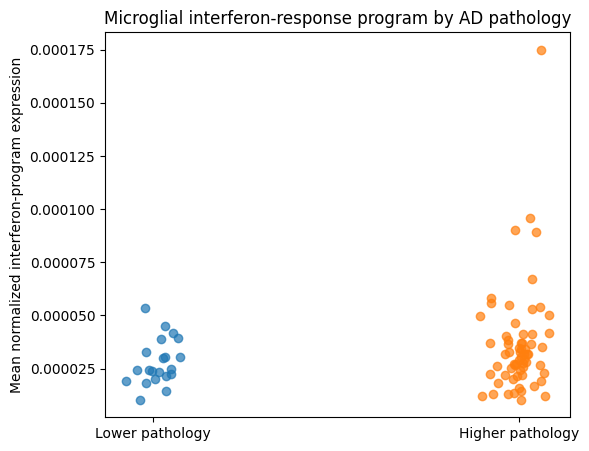

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

groups = ["Lower pathology", "Higher pathology"]

plt.figure(figsize=(6, 5))

for i, group in enumerate(groups):
    values = donor_results.loc[
        donor_results["pathology_group"] == group,
        "interferon_score"
    ]

    jitter = np.random.normal(i, 0.04, size=len(values))
    plt.scatter(jitter, values, alpha=0.7)

plt.xticks([0, 1], groups)
plt.ylabel("Mean normalized interferon-program expression")
plt.xlabel("")
plt.title("Microglial interferon-response program by AD pathology")
plt.show()

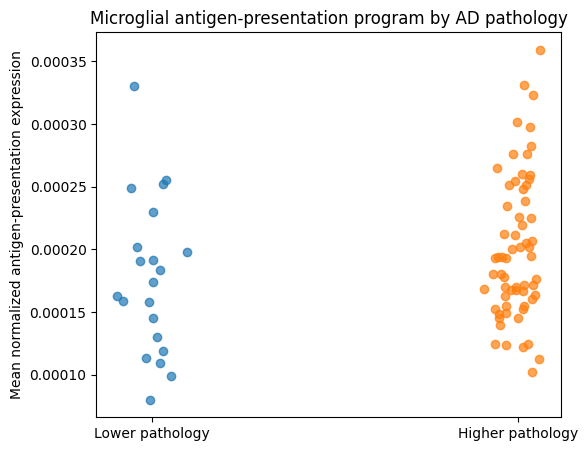

In [ ]:
plt.figure(figsize=(6, 5))

for i, group in enumerate(groups):
    values = donor_results.loc[
        donor_results["pathology_group"] == group,
        "antigen_presentation_score"
    ]

    jitter = np.random.normal(i, 0.04, size=len(values))
    plt.scatter(jitter, values, alpha=0.7)

plt.xticks([0, 1], groups)
plt.ylabel("Mean normalized antigen-presentation expression")
plt.xlabel("")
plt.title("Microglial antigen-presentation program by AD pathology")
plt.show()

In [ ]:
group_summary = (
    donor_results
    .groupby("pathology_group")[
        ["interferon_score", "antigen_presentation_score"]
    ]
    .agg(["count", "mean", "median", "std"])
)

group_summary

interferon_score                                \
                            count      mean    median       std   
pathology_group                                                   
Higher pathology               63  0.000037  0.000032  0.000025   
Lower pathology                21  0.000028  0.000025  0.000011   

                 antigen_presentation_score                                
                                      count      mean    median       std  
pathology_group                                                            
Higher pathology                         63  0.000201  0.000193  0.000057  
Lower pathology                          21  0.000178  0.000174  0.000062

In [ ]:
n_lower = len(lower)
n_higher = len(higher)

# Cliff's delta from the Mann-Whitney U statistic
delta_ifn = (2 * u_ifn) / (n_lower * n_higher) - 1
delta_ap = (2 * u_ap) / (n_lower * n_higher) - 1

print("Interferon Cliff's delta:", delta_ifn)
print("Antigen-presentation Cliff's delta:", delta_ap)

Interferon Cliff's delta: -0.21390778
Antigen-presentation Cliff's delta: -0.23053664


In [ ]:
adnc_map = {
    "Not AD": 0,
    "Low": 1,
    "Intermediate": 2,
    "High": 3
}

donor_results["adnc_numeric"] = (
    donor_results["Overall AD neuropathological Change"]
    .map(adnc_map)
)

In [ ]:
from scipy.stats import spearmanr

rho_ifn, p_ifn_trend = spearmanr(
    donor_results["adnc_numeric"],
    donor_results["interferon_score"]
)

rho_ap, p_ap_trend = spearmanr(
    donor_results["adnc_numeric"],
    donor_results["antigen_presentation_score"]
)

print("Interferon vs ADNC")
print("Spearman rho =", rho_ifn)
print("p =", p_ifn_trend)

print("\nAntigen presentation vs ADNC")
print("Spearman rho =", rho_ap)
print("p =", p_ap_trend)

Interferon vs ADNC
Spearman rho = 0.14548820658120268
p = 0.18667489449844596

Antigen presentation vs ADNC
Spearman rho = 0.1841755897307866
p = 0.0935260573097257


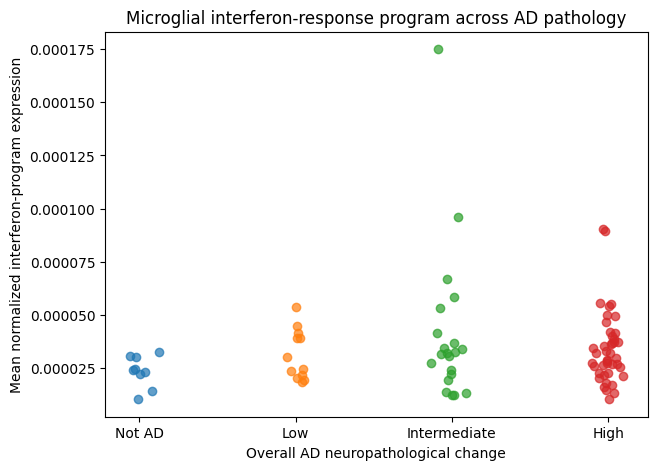

In [ ]:
adnc_order = ["Not AD", "Low", "Intermediate", "High"]

plt.figure(figsize=(7, 5))

for i, group in enumerate(adnc_order):
    values = donor_results.loc[
        donor_results["Overall AD neuropathological Change"] == group,
        "interferon_score"
    ]

    jitter = np.random.normal(i, 0.05, len(values))
    plt.scatter(jitter, values, alpha=0.7)

plt.xticks(range(4), adnc_order)
plt.xlabel("Overall AD neuropathological change")
plt.ylabel("Mean normalized interferon-program expression")
plt.title("Microglial interferon-response program across AD pathology")
plt.show()

In [ ]:
print("Missing ages:", donor_results["Age at Death"].isna().sum())

print("\nAge by pathology group:")
print(
    donor_results
    .groupby("pathology_group")["Age at Death"]
    .agg(["count", "mean", "median", "std"])
)

print("\nSex by pathology group:")
print(
    pd.crosstab(
        donor_results["pathology_group"],
        donor_results["sex"]
    )
)

Missing ages: 0

Age by pathology group:
                  count       mean  median       std
pathology_group                                     
Higher pathology     63  88.825397    90.0  7.782403
Lower pathology      21  88.428571    89.0  8.925085

Sex by pathology group:
sex               female  male
pathology_group               
Higher pathology      39    24
Lower pathology       12     9


In [ ]:
n_lower = len(lower)
n_higher = len(higher)

delta_ifn = (2 * u_ifn) / (n_lower * n_higher) - 1
delta_ap = (2 * u_ap) / (n_lower * n_higher) - 1

print("Interferon Cliff's delta:", delta_ifn)
print("Antigen-presentation Cliff's delta:", delta_ap)

Interferon Cliff's delta: -0.21390778
Antigen-presentation Cliff's delta: -0.23053664


In [ ]:
import statsmodels.formula.api as smf

# Encode pathology group as 0 = lower, 1 = higher
donor_results["higher_pathology"] = (
    donor_results["pathology_group"] == "Higher pathology"
).astype(int)

# Encode sex
donor_results["male"] = (
    donor_results["sex"].str.lower() == "male"
).astype(int)

In [ ]:
model_ifn = smf.ols(
    "interferon_score ~ higher_pathology + Q('Age at Death') + male",
    data=donor_results
).fit(cov_type="HC3")

print(model_ifn.summary())

                            OLS Regression Results                            
Dep. Variable:       interferon_score   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     1.617
Date:                Tue, 18 Aug 2026   Prob (F-statistic):              0.192
Time:                        05:05:12   Log-Likelihood:                 782.65
No. Observations:                  84   AIC:                            -1557.
Df Residuals:                      80   BIC:                            -1548.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          1.523e-06   2.14e-0

In [ ]:
model_ap = smf.ols(
    "antigen_presentation_score ~ higher_pathology + Q('Age at Death') + male",
    data=donor_results
).fit(cov_type="HC3")

print(model_ap.summary())

                                OLS Regression Results                                
Dep. Variable:     antigen_presentation_score   R-squared:                       0.043
Model:                                    OLS   Adj. R-squared:                  0.007
Method:                         Least Squares   F-statistic:                     1.177
Date:                        Tue, 18 Aug 2026   Prob (F-statistic):              0.324
Time:                                05:05:19   Log-Likelihood:                 701.16
No. Observations:                          84   AIC:                            -1394.
Df Residuals:                              80   BIC:                            -1385.
Df Model:                                   3                                         
Covariance Type:                          HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------

In [ ]:
import statsmodels.formula.api as smf

donor_results["higher_pathology"] = (
    donor_results["pathology_group"] == "Higher pathology"
).astype(int)

donor_results["male"] = (
    donor_results["sex"].str.lower() == "male"
).astype(int)

In [ ]:
model_ifn = smf.ols(
    "interferon_score ~ higher_pathology + Q('Age at Death') + male",
    data=donor_results
).fit(cov_type="HC3")

print(model_ifn.summary())

                            OLS Regression Results                            
Dep. Variable:       interferon_score   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     1.617
Date:                Tue, 18 Aug 2026   Prob (F-statistic):              0.192
Time:                        05:07:00   Log-Likelihood:                 782.65
No. Observations:                  84   AIC:                            -1557.
Df Residuals:                      80   BIC:                            -1548.
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          1.523e-06   2.14e-0

In [ ]:
model_ap = smf.ols(
    "antigen_presentation_score ~ higher_pathology + Q('Age at Death') + male",
    data=donor_results
).fit(cov_type="HC3")

print(model_ap.summary())

                                OLS Regression Results                                
Dep. Variable:     antigen_presentation_score   R-squared:                       0.043
Model:                                    OLS   Adj. R-squared:                  0.007
Method:                         Least Squares   F-statistic:                     1.177
Date:                        Tue, 18 Aug 2026   Prob (F-statistic):              0.324
Time:                                05:07:05   Log-Likelihood:                 701.16
No. Observations:                          84   AIC:                            -1394.
Df Residuals:                              80   BIC:                            -1385.
Df Model:                                   3                                         
Covariance Type:                          HC3                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------

In [ ]:
# Save donor-level results
donor_results.to_csv(
    "/content/sea_ad_microglia_donor_results.csv",
    index=False
)

print("Saved donor-level results.")

Saved donor-level results.


In [ ]:
import os

os.makedirs("/content/figures", exist_ok=True)

In [ ]:
adnc_order = ["Not AD", "Low", "Intermediate", "High"]

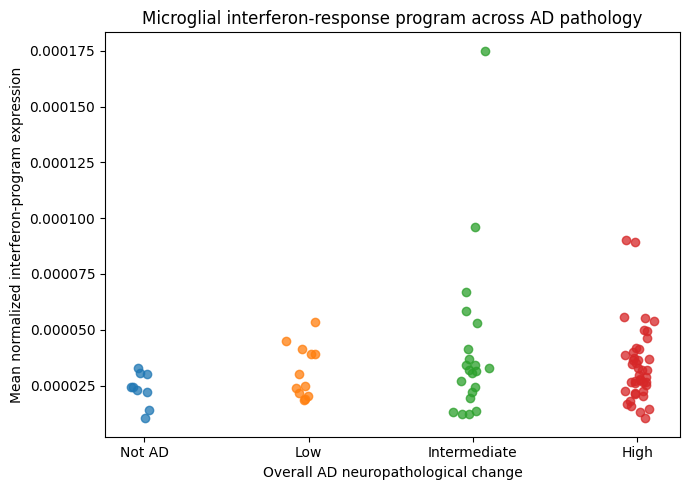

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7, 5))

for i, group in enumerate(adnc_order):
    values = donor_results.loc[
        donor_results["Overall AD neuropathological Change"] == group,
        "interferon_score"
    ]

    jitter = np.random.normal(i, 0.05, size=len(values))

    plt.scatter(
        jitter,
        values,
        alpha=0.75
    )

plt.xticks(
    range(4),
    adnc_order
)

plt.xlabel("Overall AD neuropathological change")

plt.ylabel(
    "Mean normalized interferon-program expression"
)

plt.title(
    "Microglial interferon-response program across AD pathology"
)

plt.tight_layout()

plt.savefig(
    "/content/figures/interferon_program_across_ad_pathology.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

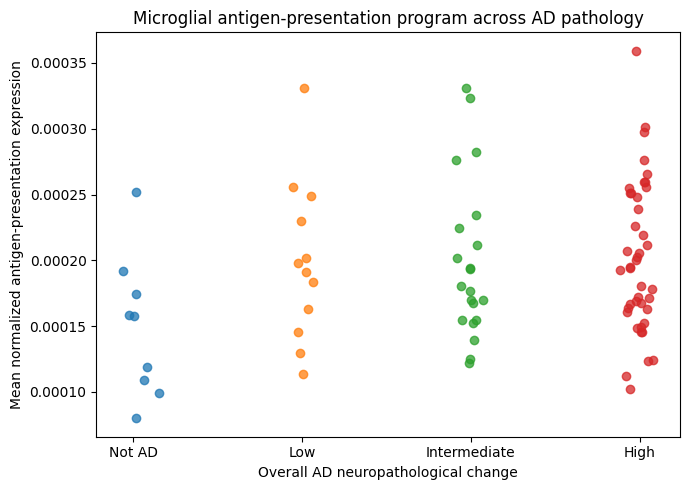

In [ ]:
plt.figure(figsize=(7, 5))

for i, group in enumerate(adnc_order):
    values = donor_results.loc[
        donor_results["Overall AD neuropathological Change"] == group,
        "antigen_presentation_score"
    ]

    jitter = np.random.normal(i, 0.05, size=len(values))

    plt.scatter(
        jitter,
        values,
        alpha=0.75
    )

plt.xticks(
    range(4),
    adnc_order
)

plt.xlabel("Overall AD neuropathological change")

plt.ylabel(
    "Mean normalized antigen-presentation expression"
)

plt.title(
    "Microglial antigen-presentation program across AD pathology"
)

plt.tight_layout()

plt.savefig(
    "/content/figures/antigen_presentation_across_ad_pathology.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
import os

print(os.listdir("/content/figures"))

['antigen_presentation_across_ad_pathology.png', 'interferon_program_across_ad_pathology.png']
